# Questions
1. Is the total followup time the same for all customers? Did some customers join the service after the recorded period started?
2. Should all the accounts in the accounts table be treated as active even if they had no streams?
3. What is the total followup time covered by the data?

# Things checked
* All account numbers in streams are in accounts

In [24]:
import polars as pl
from datetime import timedelta
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
SEED = 4130

In [25]:
accounts = pl.read_csv(
    "../Data/accounts.csv",
    null_values="NULL",
    schema_overrides={
        "account_number": pl.String,
        "price": pl.Float64,
        "churned": pl.Int64
    }
)

streams = (
    pl.read_csv(
        "../Data/streams.csv",
        null_values="NULL",
        schema_overrides={
            "account_number": pl.String,  
            "start_timestamp": pl.Int64,  
            "end_timestamp": pl.Int64,    
            "mos_score": pl.Float64
        }
    )
    .with_columns(
        pl.col("start_timestamp").cast(pl.Datetime("ms")),
        pl.col("end_timestamp").cast(pl.Datetime("ms"))
    )
)

In [26]:
accounts.head()

account_number,price,churned
str,f64,i64
"""650""",30.56,1
"""573""",12.04,0
"""575""",32.05,0
"""943""",30.56,1
"""924""",35.19,0


In [27]:
accounts['churned'].mean()

0.413

In [28]:
(
    accounts
    .group_by(has_streams = pl.col("account_number").is_in(streams["account_number"].implode()))
    .agg(
        n_users = pl.len(),
        prop_churned = pl.col("churned").mean().round(2)
    )
)

has_streams,n_users,prop_churned
bool,u32,f64
true,546,0.23
false,454,0.63


In [29]:
streams.head()

account_number,start_timestamp,end_timestamp,mos_score
str,datetime[ms],datetime[ms],f64
"""978""",2018-05-20 00:17:03.142,2018-05-20 00:18:05.544,4.531915
"""599""",2018-05-19 08:29:28.735,2018-05-19 08:42:48.844,4.595745
"""939""",2018-05-19 22:24:31.819,2018-05-19 22:29:41.833,4.06383
"""939""",2018-05-19 23:34:15.013,2018-05-19 23:59:20.750,4.468085
"""749""",2018-05-19 13:59:00.947,2018-05-19 14:32:46.937,4.595745


In [30]:
streams["mos_score"].quantile(0.1)

3.489361702127659

In [31]:
global_max_date = streams.select(pl.col("start_timestamp").dt.date().max()).item()
seven_days_ago = global_max_date - timedelta(days=7)
fourteen_days_ago = global_max_date - timedelta(days=14)
twentyone_days_ago = global_max_date - timedelta(days=21)
thirty_days_ago = global_max_date - timedelta(days=30)
sixty_days_ago = global_max_date - timedelta(days=60)

streaming_features = (
    streams
    .with_columns(
        stream_duration = (pl.col("end_timestamp") - pl.col("start_timestamp")),
        stream_date = pl.col("start_timestamp").dt.date()
    )
    .group_by(pl.col("account_number"))
    .agg(
        n_streams = pl.len(),
        total_time_streamed = pl.col("stream_duration").sum().dt.total_seconds(),
        avg_stream_length = pl.col("stream_duration").sum().dt.total_seconds() / pl.len(),
        days_streamed = pl.col("stream_date").n_unique(),
        avg_mos_score = (pl.col("mos_score") * pl.col("stream_duration")).sum() / pl.col("stream_duration").sum(),
        days_since_last_stream = (global_max_date - pl.col("stream_date").max()).dt.total_days(),
        n_poor_quality_streams = (pl.col("mos_score") < 3.5).sum(),
        n_aborted_streams = (pl.col("stream_duration").dt.total_seconds() < 300).sum(),
        max_streams_per_day = pl.col("stream_date").value_counts().struct.field("count").max(),
        avg_streams_per_active_day = pl.len() / pl.col("stream_date").n_unique(),
        streams_last_7d = (pl.col("stream_date") >= seven_days_ago).sum(),
        streams_last_14d = (pl.col("stream_date") >= fourteen_days_ago).sum(),
        streams_last_21d = (pl.col("stream_date") >= twentyone_days_ago).sum(),
        streams_last_30d = (pl.col("stream_date") >= thirty_days_ago).sum(),
        streams_last_60d = (pl.col("stream_date") >= sixty_days_ago).sum(),
    )
)
streaming_features.head()

account_number,n_streams,total_time_streamed,avg_stream_length,days_streamed,avg_mos_score,days_since_last_stream,n_poor_quality_streams,n_aborted_streams,max_streams_per_day,avg_streams_per_active_day,streams_last_7d,streams_last_14d,streams_last_21d,streams_last_30d,streams_last_60d
str,u32,i64,f64,u32,f64,i64,u32,u32,u32,f64,u32,u32,u32,u32,u32
"""826""",293,407057,1389.273038,41,4.205901,5,39,120,41,7.146341,9,9,24,37,52
"""827""",160,186674,1166.7125,33,4.54287,57,4,51,15,4.848485,0,0,0,0,8
"""158""",349,499513,1431.269341,33,4.4212,3,9,92,48,10.575758,32,141,233,249,251
"""69""",2396,3882853,1620.556344,97,4.549077,0,24,650,53,24.701031,162,302,492,650,874
"""773""",121,149304,1233.917355,10,4.118326,73,5,42,36,12.1,0,0,0,0,0


In [32]:
customer_data = (
    accounts.join(streaming_features, on="account_number", how="left", validate="1:1")
    .with_columns(
        is_inactive = (pl.col("n_streams") == 0) | pl.col("n_streams").is_null(),
        cost_per_stream = pl.col("total_time_streamed") / pl.col("price")
    )
)
customer_data.head()

account_number,price,churned,n_streams,total_time_streamed,avg_stream_length,days_streamed,avg_mos_score,days_since_last_stream,n_poor_quality_streams,n_aborted_streams,max_streams_per_day,avg_streams_per_active_day,streams_last_7d,streams_last_14d,streams_last_21d,streams_last_30d,streams_last_60d,is_inactive,cost_per_stream
str,f64,i64,u32,i64,f64,u32,f64,i64,u32,u32,u32,f64,u32,u32,u32,u32,u32,bool,f64
"""650""",30.56,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,true,null
"""573""",12.04,0,492,667736,1357.186992,61,2.122296,7,210,314,86,8.065574,2,3,22,127,175,false,55459.800664
"""575""",32.05,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,true,null
"""943""",30.56,1,8,9815,1226.875,1,1.928656,75,6,2,8,8.0,0,0,0,0,0,false,321.171466
"""924""",35.19,0,1614,1887842,1169.666667,98,4.462582,0,62,625,48,16.469388,119,205,279,430,671,false,53647.115658


In [42]:
analysis_df = customer_data.drop(pl.col(["account_number"]))

train_df, temp_df = train_test_split(
    analysis_df, 
    test_size=0.20,
    stratify=customer_data["churned"],
    random_state=SEED
)

test_df, valid_df = train_test_split(
    temp_df, 
    test_size=0.50,
    stratify=temp_df["churned"],
    random_state=SEED
)

X_train, y_train = train_df.drop("churned"), train_df.select("churned")
X_valid, y_valid = valid_df.drop("churned"), valid_df.select("churned")
X_test, y_test = test_df.drop("churned"), test_df.select("churned")

print(f"n_features: {X_train.width}")
print(f"training_customers: {X_train.height}")
print(f"validation_customers: {X_valid.height}")
print(f"test_customers: {X_test.height}")

n_features: 18
training_customers: 800
validation_customers: 100
test_customers: 100


In [34]:
base_model = xgb.XGBClassifier(
    n_estimators=500,
    eval_metric="aucpr",
    scale_pos_weight=4,
    random_state=SEED
)

param_distributions = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

tuning_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='average_precision',
    cv=3,                 
    verbose=1,
    random_state=SEED,
    n_jobs=1
)

tuning_search.fit(
    X_train,
    y_train,
    verbose=False
)

best_params = tuning_search.best_params_

Fitting 3 folds for each of 100 candidates, totalling 300 fits


In [35]:
final_model = xgb.XGBClassifier(
    n_estimators=2000,
    eval_metric="aucpr",
    early_stopping_rounds=100,
    scale_pos_weight=4,
    random_state=SEED,
    **best_params
)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=25
)

[0]	validation_0-aucpr:0.72064
[25]	validation_0-aucpr:0.71513
[50]	validation_0-aucpr:0.70844
[75]	validation_0-aucpr:0.70332
[100]	validation_0-aucpr:0.71384
[113]	validation_0-aucpr:0.71803


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

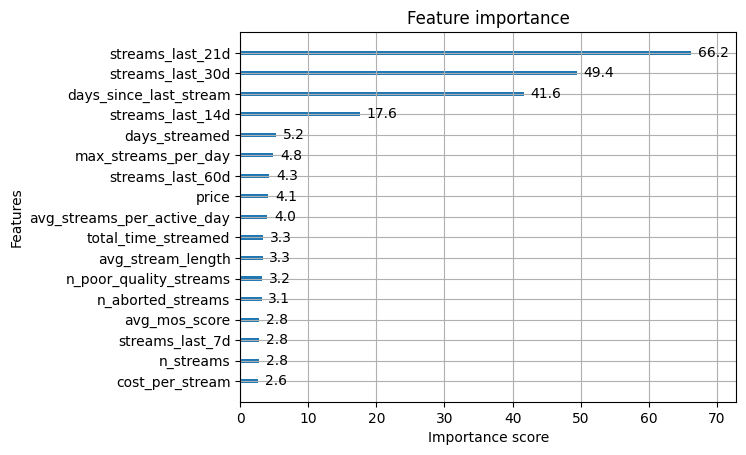

In [36]:
xgb.plot_importance(final_model, importance_type="gain", values_format="{v:.1f}")
plt.show()

In [37]:
# 1. Get the probabilities
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# 2. Calculate the Precision-Recall curve points and the overall PR-AUC
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc_score = average_precision_score(y_test, y_pred_proba)

# 3. Find the optimal threshold by maximizing the F1-score
# (Adding 1e-10 to the denominator prevents zero-division warnings)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"PR-AUC Score: {pr_auc_score:.4f}")
print(f"Optimal PR Threshold (Max F1): {optimal_threshold:.4f}\n")

# 4. Generate new hard predictions using this custom threshold
y_pred_custom = (y_pred_proba >= optimal_threshold).astype(int)

# 5. Print the classification report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom))

PR-AUC Score: 0.8026
Optimal PR Threshold (Max F1): 0.7396

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        58
           1       0.76      0.88      0.81        42

    accuracy                           0.83       100
   macro avg       0.83      0.84      0.83       100
weighted avg       0.84      0.83      0.83       100



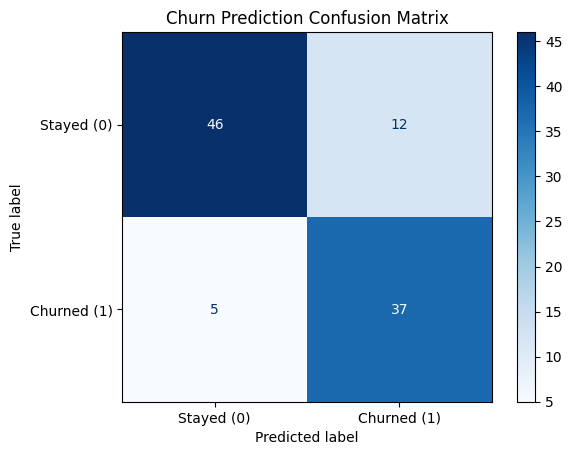

In [38]:
# Generate the raw matrix
cm = confusion_matrix(y_test, y_pred_custom)

# Plot it with labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Stayed (0)', 'Churned (1)']
)

# Use a clean colormap like 'Blues' instead of the default harsh colors
disp.plot(cmap='Blues', values_format='d') 
plt.title("Churn Prediction Confusion Matrix")
plt.show()